In [1]:
from ucimlrepo import fetch_ucirepo

In [37]:
student_per=fetch_ucirepo(id=320)
student_per

{'data': {'ids': None,
  'features':     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
  0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
  1       GP   F   17       U     GT3       T     1     1   at_home     other   
  2       GP   F   15       U     LE3       T     1     1   at_home     other   
  3       GP   F   15       U     GT3       T     4     2    health  services   
  4       GP   F   16       U     GT3       T     3     3     other     other   
  ..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
  644     MS   F   19       R     GT3       T     2     3  services     other   
  645     MS   F   18       U     LE3       T     3     1   teacher  services   
  646     MS   F   18       U     GT3       T     1     1     other     other   
  647     MS   M   17       U     LE3       T     3     1  services  services   
  648     MS   M   18       R     LE3       T     3     2  services     ot

In [39]:
x=student_per.data.features
x.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


In [40]:
y=student_per.data.targets
y

,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13
...,...,...,...
644,10,11,10
645,15,15,16
646,11,12,9
647,10,10,10


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
import sklearn.metrics as mt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [6]:
# random forest classiffier

In [41]:
y["pass"]=np.where(y["G3"]>10,1,0)

C:\Users\Acer\AppData\Local\Temp\ipykernel_37424\1936837761.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["pass"]=np.where(y["G3"]>10,1,0)


In [15]:
y.head()

,G1,G2,G3,pass
0,0,11,11,1
1,9,11,11,1
2,12,13,12,1
3,14,14,14,1
4,11,13,13,1


In [42]:
y.drop(["G1","G2","G3"],axis=1,inplace=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_37424\4182427253.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.drop(["G1","G2","G3"],axis=1,inplace=True)


In [43]:
le=LabelEncoder()
for i in x.select_dtypes(include=["object"]).columns:
    x[i]=le.fit_transform(x[i])

C:\Users\Acer\AppData\Local\Temp\ipykernel_37424\2671254253.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[i]=le.fit_transform(x[i])
C:\Users\Acer\AppData\Local\Temp\ipykernel_37424\2671254253.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[i]=le.fit_transform(x[i])
C:\Users\Acer\AppData\Local\Temp\ipykernel_37424\2671254253.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [46]:
rf=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=5) # n_estimators no of trees using  in random forest model

In [47]:
rf.fit(x_train,y_train)

C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=5, random_state=42)

In [49]:
y_pread=rf.predict(x_test)
y_pread

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [51]:
print(f"Accuracy score:{accuracy_score(y_test,y_pread)}")

Accuracy score:0.8


In [53]:
print(f"{classification_report(y_test,y_pread)}")

              precision    recall  f1-score   support

           0       0.65      0.41      0.50        32
           1       0.83      0.93      0.88        98

    accuracy                           0.80       130
   macro avg       0.74      0.67      0.69       130
weighted avg       0.78      0.80      0.78       130



In [61]:
feat_imp=pd.Series(rf.feature_importances_,index=x.columns).sort_values(ascending=False)
feat_imp 

failures      0.242296
school        0.108571
higher        0.064557
absences      0.060918
Fedu          0.054399
Medu          0.041223
Mjob          0.039432
Dalc          0.035213
age           0.035017
Walc          0.032018
studytime     0.030278
traveltime    0.026280
famrel        0.025088
freetime      0.024320
guardian      0.020499
goout         0.018588
Fjob          0.017417
health        0.016551
reason        0.015541
sex           0.013708
address       0.011314
internet      0.010084
romantic      0.008992
nursery       0.008947
activities    0.008828
famsize       0.008177
schoolsup     0.007654
famsup        0.005210
Pstatus       0.004992
paid          0.003888
dtype: float64

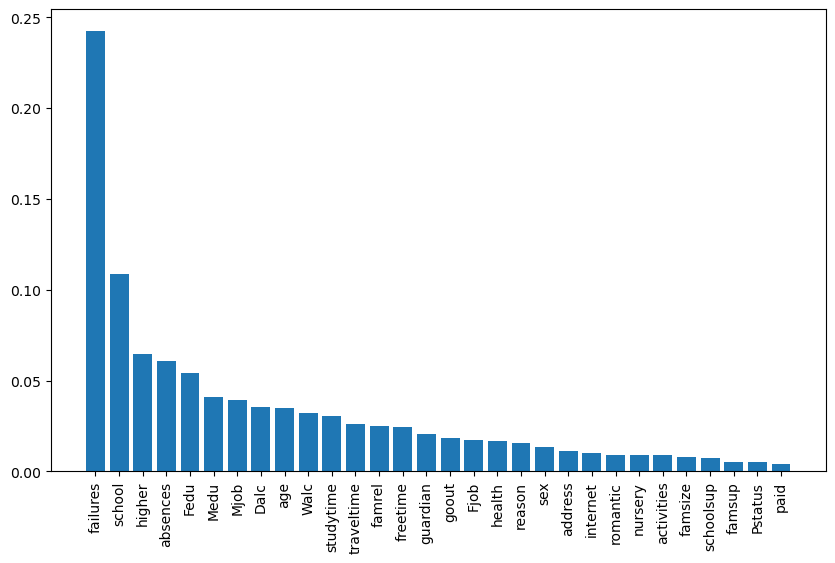

In [60]:
plt.figure(figsize=(10,6))
plt.bar(feat_imp.index,feat_imp.values)
plt.xticks(rotation=90)
plt.show()